<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 06 — Upload two-model-agreed clips to the platform

Take the rows from `04c_models_agree.ipynb` (where our zh checkpoint and
pipecat-v3 agree on the label), rank them **pipecat-first, then ours**,
and post each one to the WaveKat platform as an auto-labelled annotation
with a `confidence` score.

The platform's records UI knows about `source = 'pre_labeled'` and a
per-row `confidence` (see `wavekat-platform/services/api/migrations/0012_annotation_confidence.sql`)
and lets a reviewer triage low-confidence rows first.

## What this notebook needs

1. A platform account with a project the upload should land in, and a
   label set on that project that defines `continuation` and
   `end_of_turn` keys (matching the binary labels we predict here).
2. A `wkcli_…` bearer token. The platform UI does **not** currently
   expose a manual "mint a token" button — tokens are issued through
   the `wk login` loopback flow:
   ```bash
   # Mint a token against your local platform:
   WK_BASE_URL=https://localhost:5020 wk login
   # …or against the deployed one:
   wk login   # defaults to https://platform.wavekat.com
   ```
   `wk login` opens your browser for GitHub auth, the platform mints
   the token, and the CLI persists it to
   `~/Library/Application Support/wavekat/auth.json` (macOS — see
   `wavekat-cli/src/config.rs:30` for the per-OS path).
3. A `.env` (alongside this repo's existing `.env`) with the token
   copied out of `auth.json`. Easiest one-liner:
   ```bash
   WAVEKAT_API_URL=https://localhost:5020
   WAVEKAT_API_TOKEN=$(jq -r .token "$HOME/Library/Application Support/wavekat/auth.json")
   WAVEKAT_PROJECT_ID=<paste from the platform UI>
   ```
   Make sure `WAVEKAT_API_URL` matches the host the token was minted
   against — a token issued by the local platform won't work against
   the production one and vice-versa.
4. The local MagicData-RAMC WAV files. The clip bytes are sliced from
   the same path that `04c` reads.

In [1]:
from __future__ import annotations

import hashlib
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import soundfile as sf
from tqdm.auto import tqdm

MINING_ROOT  = Path("../../datasets/smart-turn-zh-mining").resolve()
AGREED_IN    = MINING_ROOT / "candidates_models_agree.parquet"
WAV_DIR      = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

# Load WAVEKAT_* from a `.env` walking up from this notebook (same pattern
# as 05_score_llm.ipynb). `override=False` so an already-exported shell
# value wins over `.env`.
try:
    from dotenv import find_dotenv, load_dotenv
    dotenv_path = find_dotenv(usecwd=True)
    if dotenv_path:
        load_dotenv(dotenv_path, override=False)
        print(f"loaded .env  : {Path(dotenv_path).name} (from {Path(dotenv_path).parent.name}/)")
    else:
        print("loaded .env  : (none found — relying on shell environment)")
except ImportError:
    print("loaded .env  : (python-dotenv not installed — relying on shell environment)")

# Platform endpoint + auth. Default to the local dev URL so a wrong env
# var doesn't accidentally fire writes at production.
PLATFORM_BASE_URL = os.environ.get("WAVEKAT_API_URL", "https://localhost:5020").rstrip("/")
PLATFORM_TOKEN    = os.environ.get("WAVEKAT_API_TOKEN")
PROJECT_ID        = os.environ.get("WAVEKAT_PROJECT_ID")

# Cap the upload run. Default is large enough to cover the full agreed set
# (~couple of thousand rows). Set MAX_UPLOADS in the environment to a
# smaller number when you want a quick smoke test instead of a real run.
MAX_UPLOADS = int(os.environ.get("MAX_UPLOADS", "100000"))

# Map our binary {0, 1} labels to the platform label-set keys. The label
# set on the project must define exactly these keys for the create call to
# succeed.
LABEL_KEY_BY_PRED = {0: "continuation", 1: "end_of_turn"}

print(f"agreed parquet : {AGREED_IN.name} (exists={AGREED_IN.exists()})")
print(f"wav dir        : {WAV_DIR.name}/  (exists={WAV_DIR.exists()})")
print(f"platform       : {PLATFORM_BASE_URL}")
print(f"token set      : {bool(PLATFORM_TOKEN)}")
print(f"project id     : {PROJECT_ID or '(unset — set WAVEKAT_PROJECT_ID)'}")
print(f"max uploads    : {MAX_UPLOADS}")
print("✅ config loaded")

loaded .env  : .env (from wavekat-lab/)
agreed parquet : candidates_models_agree.parquet (exists=True)
wav dir        : WAV/  (exists=True)
platform       : https://platform.wavekat.com
token set      : True
project id     : a3eab11d-fb5f-4f56-ad04-fafa004c8f11
max uploads    : 100000
✅ config loaded


In [2]:
# Ping /api/me — the cheapest possible "does my token work?" check.
# A 401 here means the token is wrong / revoked / minted against a
# different platform host (e.g. token from prod, URL pointing at local).
# Run this on its own first; only continue if it returns your login.
if not PLATFORM_TOKEN:
    raise SystemExit("WAVEKAT_API_TOKEN is unset — mint one with `wk login --base-url …` and export it.")

session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {PLATFORM_TOKEN}",
    "User-Agent": "wavekat-lab/06-upload-notebook",
})

me = session.get(f"{PLATFORM_BASE_URL}/api/me", timeout=10)
if me.status_code == 401:
    raise SystemExit(
        f"401 from {PLATFORM_BASE_URL}/api/me — token rejected.\n"
        f"  • Was the token minted against this host? (tokens are scoped to a single platform.)\n"
        f"  • Has it been revoked? Mint a fresh one: `WK_BASE_URL={PLATFORM_BASE_URL} wk login`."
    )
me.raise_for_status()
me_json = me.json()
print(f"authenticated as : {me_json.get('login')}  (role={me_json.get('role')}, id={me_json.get('id')})")
print("✅ token works")

authenticated as : wavekat-eason  (role=root, id=220911746)
✅ token works


In [3]:
# Verify the destination project + its active label set. Split out from the
# /me ping so a project-config issue doesn't masquerade as an auth failure.
if not PROJECT_ID:
    raise SystemExit("WAVEKAT_PROJECT_ID is unset — set it to the destination project's id.")

proj = session.get(f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}", timeout=10)
if proj.status_code == 404:
    raise SystemExit(
        f"404 on project {PROJECT_ID} — either the id is wrong, or your account "
        f"isn't a member of that project (the API returns 404, not 403, to avoid leaking existence)."
    )
proj.raise_for_status()
proj_json = proj.json()
print(f"project          : {proj_json.get('name')}  (role={proj_json.get('myRoleInProject')})")
active_label_set_id = proj_json.get("activeLabelSetId")
if not active_label_set_id:
    raise SystemExit("project has no active label set — pick one in the platform UI first.")

ls = session.get(f"{PLATFORM_BASE_URL}/api/label-sets/{active_label_set_id}", timeout=10)
ls.raise_for_status()
ls_json = ls.json()
label_keys = {l["key"] for l in ls_json.get("labels", [])}
missing = set(LABEL_KEY_BY_PRED.values()) - label_keys
if missing:
    raise SystemExit(
        f"active label set '{ls_json.get('name')}' is missing required keys: {sorted(missing)}"
    )
print(f"label set        : {ls_json.get('name')}  (keys: {sorted(label_keys)})")
print("✅ project + label set verified")

project          : MagicData-RAMC - Auto Label #2  (role=root)
label set        : Turn Detection V1  (keys: ['continuation', 'end_of_turn'])
✅ project + label set verified


In [ ]:
# Build the upload queue from 04c's agreed rows. Two knobs:
#
# 1. CONFIDENCE_MIN / CONFIDENCE_MAX  — restrict to a confidence band.
#    Confidence here is the joint probability under both models for the
#    chosen label:
#      EOT  : P(EOT|pipecat)  * P(EOT|ours)  = pipecat_prob       * model_prob
#      CONT : P(CONT|pipecat) * P(CONT|ours) = (1 - pipecat_prob) * (1 - model_prob)
#    Treating the two votes as independent collapses to a single [0, 1]
#    number that the records-UI confidence column can rank by. Default
#    band is [0.0, 1.0] (everything); tighten to e.g. [0.5, 0.6] when
#    you want to focus a run on the borderline strip a human reviewer
#    is most useful for.
#
# 2. Round-robin interleave  — the platform should accumulate a balanced
#    sample even if a run is cancelled partway, so we zip per-label
#    queues (each ranked by confidence DESC) instead of stacking them:
#       upload[0] = label A best, [1] = label B best, [2] = label A 2nd, …
#
# Run this cell, *eyeball the per-label counts*, and only run the
# upload cell below if the band has the volume + balance you want.
agreed = pd.read_parquet(AGREED_IN)

pp = agreed["pipecat_prob"].astype(float)
mp = agreed["model_prob"].astype(float)
is_eot = agreed["model_pred"] == 1
agreed["confidence"] = np.where(is_eot, pp * mp, (1.0 - pp) * (1.0 - mp))

CONFIDENCE_MIN = float(os.environ.get("CONFIDENCE_MIN", "0.0"))
CONFIDENCE_MAX = float(os.environ.get("CONFIDENCE_MAX", "1.0"))
in_band = (agreed["confidence"] >= CONFIDENCE_MIN) & (agreed["confidence"] <= CONFIDENCE_MAX)
banded = agreed[in_band].copy()

print(f"agreed rows total : {len(agreed)}")
print(f"confidence band   : [{CONFIDENCE_MIN:.3f}, {CONFIDENCE_MAX:.3f}]  "
      f"(env: CONFIDENCE_MIN, CONFIDENCE_MAX)")
print(f"rows in band      : {len(banded)}")
print("  by label:")
per_label_counts = {}
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    n = int((banded["model_pred"] == pred).sum())
    per_label_counts[label_key] = n
    print(f"    {label_key:>12} : {n}")

# Per-label queues, ranked by confidence DESC. Stable mergesort so ties
# preserve the parquet's original order.
per_label_queues = [
    banded[banded["model_pred"] == pred]
    .sort_values("confidence", ascending=False, kind="mergesort")
    .reset_index(drop=True)
    for pred, _ in sorted(LABEL_KEY_BY_PRED.items())
]

# Round-robin: tag each row with (round_idx, label_idx) and stable-sort
# so round 0 across all labels comes first, then round 1, etc. Vectorised
# so it stays cheap on the full ~21k row set.
parts = []
for label_idx, q in enumerate(per_label_queues):
    q = q.copy()
    q["_round"] = np.arange(len(q))
    q["_label_idx"] = label_idx
    parts.append(q)
interleaved = (
    pd.concat(parts, ignore_index=True)
    .sort_values(["_round", "_label_idx"], kind="mergesort")
    .drop(columns=["_round", "_label_idx"])
    .reset_index(drop=True)
)

to_upload = interleaved.head(MAX_UPLOADS).reset_index(drop=True)
print(f"\nqueued for upload : {len(to_upload)}  (cap MAX_UPLOADS={MAX_UPLOADS})")
print(f"  by label (queued):")
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    n = int((to_upload["model_pred"] == pred).sum())
    print(f"    {label_key:>12} : {n}")
if len(to_upload):
    print(f"confidence range  : "
          f"min={to_upload['confidence'].min():.3f}, "
          f"median={to_upload['confidence'].median():.3f}, "
          f"max={to_upload['confidence'].max():.3f}")

# Preview the first 10 — the model_pred column should alternate label
# values, confirming the round-robin is wired up correctly.
print("✅ upload queue built — review counts above before running the upload cell")
to_upload[["session_id", "model_pred", "confidence", "pipecat_prob", "model_prob",
           "clip_start_s", "clip_end_s", "text"]].head(10)

queued clips     : 21811
duration min     : 1.000s
duration p50     : 2.455s
duration p90     : 5.048s
duration p99     : 7.503s
duration max     : 8.000s
✅ all clips ≤ 8s — match the model's input window and the platform's bucketing


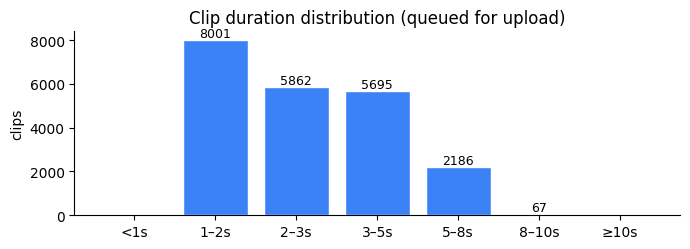

✅ duration distribution shown


In [5]:
# Sanity-check the clip-duration distribution before we PUT anything to
# the platform. 03_build_candidates caps clips at CLIP_MAX_S = 8.0s, so a
# row above 8s would mean the parquet was regenerated with a wider window
# (or that we widened the upload range here, which we don't currently do).
# The platform's records-tab "duration" filter buckets at 8s, so anything
# >8s would only appear under the ≥10s bucket — useful to catch early.
import matplotlib.pyplot as plt

durations = (to_upload["clip_end_s"] - to_upload["clip_start_s"]).astype(float)
print(f"queued clips     : {len(durations)}")
print(f"duration min     : {durations.min():.3f}s")
print(f"duration p50     : {durations.median():.3f}s")
print(f"duration p90     : {durations.quantile(0.90):.3f}s")
print(f"duration p99     : {durations.quantile(0.99):.3f}s")
print(f"duration max     : {durations.max():.3f}s")
n_over_8 = int((durations > 8.0).sum())
if n_over_8:
    print(f"⚠️  {n_over_8} clip(s) exceed 8s — the platform's duration filter "
          f"will lump these into its ≥10s bucket")
else:
    print("✅ all clips ≤ 8s — match the model's input window and the platform's bucketing")

# Buckets line up with the records-tab DurationBucket choices on the
# platform so the chart and the UI tell the same story.
edges = [0, 1, 2, 3, 5, 8, 10, max(10.001, float(durations.max()) + 0.001)]
labels = ["<1s", "1–2s", "2–3s", "3–5s", "5–8s", "8–10s", "≥10s"]
counts, _ = np.histogram(durations, bins=edges)

fig, ax = plt.subplots(figsize=(7, 2.6))
bars = ax.bar(labels, counts, color="#3b82f6", edgecolor="white")
for bar, c in zip(bars, counts):
    if c:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{c}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("clips")
ax.set_title("Clip duration distribution (queued for upload)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ duration distribution shown")

In [6]:
# Per-session helpers: hash the WAV once (the platform dedupes by
# sha256), and remember the file row id so we don't refetch on every
# clip. The `files` POST is idempotent so a re-run is cheap, but a single
# session yields 50+ clips — caching keeps the run snappy.
import functools

_HASH_CHUNK = 1024 * 1024  # 1 MB — keep memory bounded for large session WAVs.

@functools.lru_cache(maxsize=None)
def session_wav_meta(session_id: str) -> dict:
    path = WAV_DIR / f"{session_id}.wav"
    info = sf.info(str(path))
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(_HASH_CHUNK)
            if not chunk:
                break
            h.update(chunk)
    return {
        "path": path,
        "sha256": h.hexdigest(),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.frames) / float(info.samplerate),
    }

@functools.lru_cache(maxsize=None)
def upsert_file(session_id: str) -> str:
    """Create-or-get the platform `files` row for a session WAV; return its id."""
    meta = session_wav_meta(session_id)
    body = {
        "name": session_id,
        "originalFilename": f"{session_id}.wav",
        "sha256": meta["sha256"],
        "durationSec": meta["duration_sec"],
        "sampleRate": meta["sample_rate"],
        "channelCount": meta["channels"],
    }
    r = session.post(
        f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/files",
        json=body, timeout=15,
    )
    r.raise_for_status()
    j = r.json()
    return j["id"]

def slice_wav_bytes(session_id: str, start_s: float, end_s: float) -> bytes:
    """Read [start_s, end_s) from the source WAV and re-emit a 16-bit PCM
    WAV blob. Mono-mixes the source so the clip stays small and the
    server-side WAV-meta parse stays in the supported codec list."""
    meta = session_wav_meta(session_id)
    sr = meta["sample_rate"]
    start  = max(0, int(start_s * sr))
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(meta["path"]), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV", subtype="PCM_16")
    return buf.getvalue()

print("✅ helpers ready")

✅ helpers ready


In [ ]:
# Upload loop. Each row: ensure the session file exists on the platform,
# create the annotation row with source=pre_labeled + confidence, then
# PUT the sliced WAV bytes. Two HTTP round-trips per clip — at ~1 RPS
# each that's ~5 hours for the full agreed set, so we parallelise the
# per-clip work with a thread pool. Network-I/O bound, so threads scale
# fine; results come back in submission order via `executor.map`.
#
# Range is `[clip_start_s, clip_end_s]` straight from the parquet — the
# same slice that 04c plays in its audio embeds and that the model scored
# on. `clip_start_s` is already snapped to the parent utterance's start
# (or `clip_end_s - 8s`, whichever is later) by 03_build_candidates, so
# no widening here.
import concurrent.futures
from requests.adapters import HTTPAdapter

# Bump the Session's connection pool above the default 10 so worker
# threads don't queue on a single shared HTTPS connection. requests.Session
# is safe for concurrent use once the pool is sized for the workers.
_adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64, max_retries=0)
session.mount("https://", _adapter)
session.mount("http://", _adapter)

# Pre-warm `upsert_file` for every unique session WAV. The slow part is
# the local SHA-256 hash of the source WAV; doing it once up-front keeps
# the upload threads from all racing to hash the same file (lru_cache
# only memoises *after* the first call returns).
unique_sessions = sorted(set(to_upload["session_id"].astype(str)))
print(f"pre-warming {len(unique_sessions)} session file(s)…")
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as _ex:
    list(tqdm(_ex.map(upsert_file, unique_sessions),
              total=len(unique_sessions), desc="files", unit="file"))

UPLOAD_WORKERS = int(os.environ.get("UPLOAD_WORKERS", "16"))


def _upload_one(row_tuple):
    _, row = row_tuple
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    confidence = float(row["confidence"])
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")[:4000]

    try:
        file_id = upsert_file(sid)
        create_body = {
            "labelKey":   label_key,
            "startSec":   start_s,
            "endSec":     end_s,
            "asrText":    asr_text or None,
            "source":     "pre_labeled",
            "confidence": confidence,
            "notes": (
                f"smart-turn-mining 04c agreement\n"
                f"ours_prob={float(row['model_prob']):.4f}, "
                f"pipecat_prob={float(row['pipecat_prob']):.4f}, "
                f"gold_label={row.get('label')}"
            ),
        }
        r = session.post(
            f"{PLATFORM_BASE_URL}/api/files/{file_id}/annotations",
            json=create_body, timeout=30,
        )
        r.raise_for_status()
        ann_id = r.json()["id"]

        wav_bytes = slice_wav_bytes(sid, start_s, end_s)
        u = session.put(
            f"{PLATFORM_BASE_URL}/api/annotations/{ann_id}/clip",
            data=wav_bytes,
            headers={"Content-Type": "audio/wav"},
            timeout=60,
        )
        u.raise_for_status()
        return {
            "ok": True, "annotation_id": ann_id, "label": label_key,
            "confidence": confidence, "bytes": len(wav_bytes),
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
        }
    except requests.HTTPError as e:
        body = getattr(e.response, "text", "")
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"HTTP {e.response.status_code}: {body[:200]}",
        }
    except Exception as e:
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"{type(e).__name__}: {e}",
        }


results: list[dict] = []
ok_count = 0
fail_count = 0

rows = list(to_upload.iterrows())
pbar = tqdm(total=len(rows), desc="upload", unit="clip")
with concurrent.futures.ThreadPoolExecutor(max_workers=UPLOAD_WORKERS) as ex:
    # `executor.map` preserves submission order and the iteration runs in
    # the main thread, so appending to `results` doesn't need a lock.
    for res in ex.map(_upload_one, rows):
        results.append(res)
        if res["ok"]:
            ok_count += 1
        else:
            fail_count += 1
        pbar.set_postfix(ok=ok_count, fail=fail_count, refresh=False)
        pbar.update(1)
pbar.close()

results_df = pd.DataFrame(results)
print(f"uploaded ok : {ok_count}")
print(f"failed      : {fail_count}  (workers={UPLOAD_WORKERS})")
if fail_count:
    # Surface the first few failures inline — much easier than hunting
    # through a 1000-row results_df for the broken ones.
    print("\nfirst failures:")
    display(results_df[~results_df["ok"]].head(5))
print("✅ upload run complete")
results_df.head(20)

In [ ]:
# Sanity-check: re-fetch the project's auto-labelled rows ordered by
# confidence ASC (the records UI's triage view) and show the lowest-
# confidence ones first. If the upload landed, these should include rows
# we just wrote.
r = session.get(
    f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/annotations",
    params={
        "page": 1,
        "pageSize": 20,
        "source": "auto",
        "orderBy": "confidence",
        "order": "asc",
    },
    timeout=15,
)
r.raise_for_status()
page = r.json()
print(f"project auto-labelled total : {page['total']}")
if page['annotations']:
    cols = ["labelKey", "confidence", "reviewStatus", "startSec", "endSec", "fileName"]
    display(pd.DataFrame(page['annotations'])[cols].head(20))
print("✅ verified via the records-list endpoint")